In [79]:
import lib_dasilva2026
import numpy as np
import importlib
importlib.reload(lib_dasilva2026)

<module 'lib_dasilva2026' from '/home/dedasilv/current_projects/tracers-dispersion-detection/lib_dasilva2026.py'>

In [13]:
lib_dasilva2026.load_data?

Signature: lib_dasilva2026.load_data(aci_file, ead_file)
Docstring: <no docstring>
File:      ~/current_projects/tracers-dispersion-detection/lib_dasilva2026.py
Type:      function

In [15]:
tracers_data = lib_dasilva2026.load_data(
    aci_file='data/myrun/aci/ts2_l2_aci_ipd_20251116_v1.0.0.cdf',
    ead_file='data/myrun/ead/ts2_def_ead_20251116_v0.10.1.cdf',
)

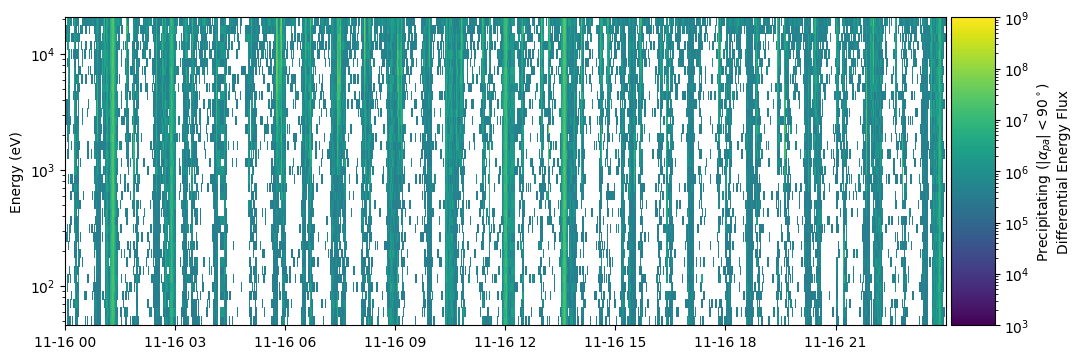

In [17]:
lib_dasilva2026.plot_spect(tracers_data)

In [21]:
Eic = lib_dasilva2026.find_Eic(tracers_data, smooth=True)

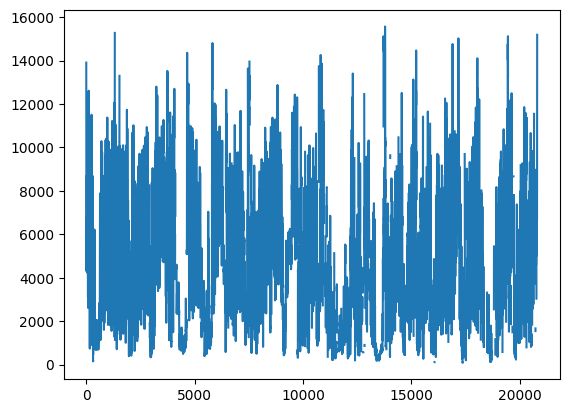

In [23]:
import pylab as plt
plt.plot(Eic)

In [26]:
tracers_data.time

array([datetime.datetime(2025, 11, 16, 0, 0, 8, 344680),
       datetime.datetime(2025, 11, 16, 0, 0, 48, 286778),
       datetime.datetime(2025, 11, 16, 0, 1, 28, 228880), ...,
       datetime.datetime(2025, 11, 16, 23, 58, 8, 227695),
       datetime.datetime(2025, 11, 16, 23, 58, 48, 169822),
       datetime.datetime(2025, 11, 16, 23, 59, 28, 111956)],
      shape=(20810,), dtype=object)

In [176]:
def get_iflux_at_Eic(data, Eic):
    iflux_at_Eic = np.zeros_like(Eic)
    for i in range(data.spect.shape[0]):
        if np.isnan(Eic[i]):
            iflux_at_Eic[i] = np.nan
        else:
            iflux_at_Eic[i] = data.spect[i, np.searchsorted(data.energies, Eic[i])]
    return iflux_at_Eic

In [188]:
MAX_SHEATH_ENERGY = 3.1e3
MIN_ION_VALID_ENERGY = 50
MIN_AVG_IFLUX_SHEATH = 10**6
MIN_IFLUX_AT_EIC = 10**5          


def test_detection(tracers_data, start_time, end_time):
    data_subset = tracers_data.subset(start_time, end_time)
    Eic = lib_dasilva2026.find_Eic(data_subset, smooth=True, window_size=11)
    ch_i = tracers_data.energies.searchsorted(MIN_ION_VALID_ENERGY)
    ch_j = tracers_data.energies.searchsorted(MAX_SHEATH_ENERGY)
    iflux_avg_sheath = np.mean(data_subset.spect.T[ch_i:ch_j, :], axis=0)
    iflux_peak_sheath = np.max(data_subset.spect.T[ch_i:ch_j, :], axis=0)
    iflux_at_Eic = get_iflux_at_Eic(data_subset, Eic)
    
    iflux_avg_sheath_mask = iflux_avg_sheath > MIN_AVG_IFLUX_SHEATH
    iflux_at_Eic_mask = iflux_at_Eic > MIN_IFLUX_AT_EIC
    Eic_in_sheath_mask = Eic < MAX_SHEATH_ENERGY
    mask = iflux_avg_sheath_mask & iflux_at_Eic_mask & Eic_in_sheath_mask
    
    delta_t = [dt.total_seconds() for dt in np.diff(data_subset.time)]   
    D = np.diff(np.log10(Eic)) / delta_t
    D *= - np.sign(np.diff(data_subset.mlat))
    D[~mask[:-1]] = 0
    D[Eic[:-1] > MAX_SHEATH_ENERGY] = 0

    
    fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
    lib_dasilva2026.plot_spect(data_subset, fig=fig, ax=axes[0])
    axes[0].plot(data_subset.time[:-1][D != 0], Eic[:-1][D != 0], 'b-', label='$E_{ic}$')
    axes[0].axhline(MAX_SHEATH_ENERGY, color='k', linestyle='dashed', label='Maximum Energy]\nfor Sheath Origin')
    
    axes[1].plot(data_subset.time, iflux_avg_sheath, label='Below Threshold')
    axes[1].plot(data_subset.time[iflux_avg_sheath_mask], iflux_avg_sheath[iflux_avg_sheath_mask], 
                 color='orange' , label='Above Thershold')
    axes[1].set_title('Average Ion Flux in Sheath Origin Energy Range')
    axes[1].set_ylabel('Averaged Omni Flux')

    axes[2].plot(data_subset.time, iflux_at_Eic, label='Below Threshold')
    axes[2].plot(data_subset.time[iflux_at_Eic_mask], iflux_at_Eic[iflux_at_Eic_mask], 
                 color='orange' , label='Above Thershold')
    axes[2].set_title('Ion Flux at Eic')
    axes[2].set_ylabel('Omni Flux')
    
    label = r'D(T) : Scoring Function'
    label += '\nTotal Score: %.2f' % np.sum(D * delta_t)
    axes[3].plot(data_subset.time[:-1], D, label=label)
    axes[3].set_ylabel('D(t)')
    for ax in axes:
        ax.legend()


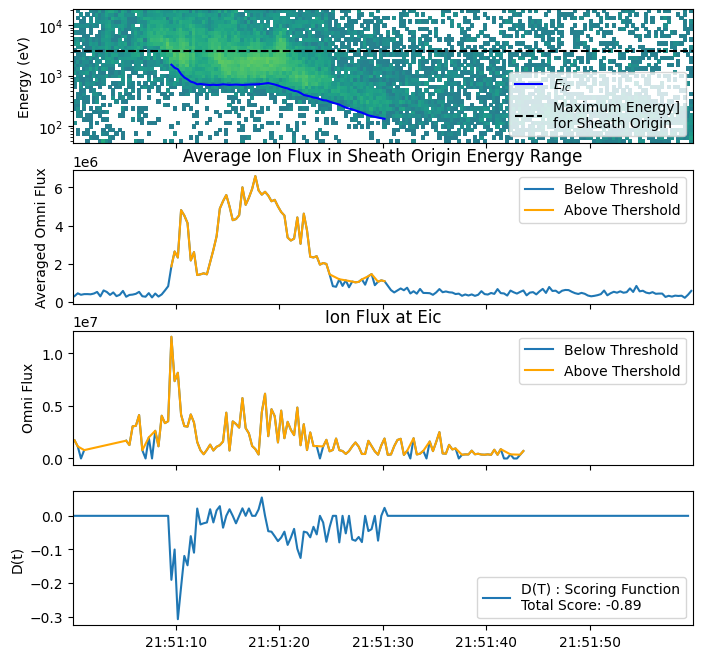

In [189]:
from datetime import datetime

start_time = datetime(2025, 11, 16, 21, 51)
end_time = datetime(2025, 11, 16, 21, 52)

test_detection(tracers_data, start_time, end_time)